In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja  # noqa: F401

pd.set_option("display.max_columns", None)

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

from src.preprocessing.run_pipeline import run_pipeline
from src.visualization.similar_properties import find_similar_properties

In [2]:
df = run_pipeline()
print(f"shape: {df.shape}")
assert "取引年" in df.columns, "取引年がない → featture_enginnering 修正反映を確認"
df.head(3)

shape: (39659, 35)


,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引年,取引四半期,log_面積,log_最寄駅：距離,築年数^2,中心地_距離,山手線内側,容積消化率（％）,log_建ぺい率,log_容積率,容積距離
0,中古マンション等,1,13101,小伝馬町,2.0,59000000,45,2014.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,12.0,35.690737,139.778433,東京都千代田区岩本町,1.0,1,1,1,0,2025,1,3.806662,0.693147,144.0,1.469402,1,7.5,4.382027,6.39693,1200.0
1,中古マンション等,1,13101,岩本町,4.0,120000000,55,2023.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,3.0,35.695534,139.775866,東京都千代田区岩本町,2.0,1,1,1,0,2025,1,4.007333,1.386294,9.0,1.775066,1,7.5,4.382027,6.39693,2400.0
2,中古マンション等,1,13101,岩本町,5.0,38000000,40,2007.0,RC,住宅,住宅,商業系,80.0,600.0,NaN,19.0,35.695534,139.775866,東京都千代田区岩本町,1.0,0,1,1,0,2025,1,3.688879,1.609438,361.0,1.775066,1,7.5,4.382027,6.39693,3000.0


In [3]:
"""対象物件の設定"""

# パターンA：都心の標準的な中古マンション
target_a = df[
  (df["種類"] == "中古マンション等")
  & (df["市区町村コード"] == 13113)  # 渋谷区
  & (df["面積（㎡）"].between(50, 70))
].head(1)

# パターンB：郊外の小規模物件
target_b = df[
  (df["種類"] == "中古マンション等")
  & (df["市区町村コード"] == 13213)  # 東村山市
].head(1)

# パターンC：希少物件（面積が大きい / 種類が違う）
target_c = df[df["面積（㎡）"] > 200].head(1)

for label, t in [("A:都心", target_a), ("B:郊外", target_b), ("C:希少:", target_c)]:
  print(f"---{label}---")
  print(t[["種類", "市区町村コード", "住所", "面積（㎡）", "築年数"]].iloc[0])

---A:都心---
種類          中古マンション等
市区町村コード        13113
住所         東京都渋谷区大山町
面積（㎡）             60
築年数              7.0
Name: 20458, dtype: object
---B:郊外---
種類            中古マンション等
市区町村コード          13213
住所         東京都東村山市多摩湖町
面積（㎡）               65
築年数               33.0
Name: 37727, dtype: object
---C:希少:---
種類           中古マンション等
市区町村コード         13101
住所         東京都千代田区四番町
面積（㎡）             260
築年数              19.0
Name: 535, dtype: object


In [4]:
# 類似5件を抽出
target_idx = target_a.index[0]
similar = find_similar_properties(df, target_idx=target_idx, n_neighbors=5)
similar

,種類,価格情報区分,市区町村コード,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,改装,築年数,最寄駅：緯度,最寄駅：経度,住所,room_count,has_L,has_D,has_K,has_S,取引年,取引四半期,log_面積,log_最寄駅：距離,築年数^2,中心地_距離,山手線内側,容積消化率（％）,log_建ぺい率,log_容積率,容積距離,similarity_distance
21005,中古マンション等,1,13113,西新宿五丁目,5.0,130000000,60,2019.0,RC,住宅,住宅,商業系,80.0,500.0,NaN,7.0,35.689798,139.684304,東京都渋谷区本町,2.0,1,1,1,0,2025,4,4.094345,1.609438,49.0,7.540403,0,6.25,4.382027,6.214608,2500.0,0.000000
21285,中古マンション等,1,13113,恵比寿,5.0,220000000,60,2020.0,RC,住宅,住宅,住居系,60.0,300.0,NaN,6.0,35.646685,139.710070,東京都渋谷区恵比寿南,2.0,1,1,1,0,2025,4,4.094345,1.609438,36.0,6.428661,1,5.00,4.094345,5.703782,1500.0,0.061734
21415,中古マンション等,0,13113,代々木上原,5.0,120000000,55,2019.0,RC,住宅,住宅,住居系,60.0,300.0,0.0,7.0,35.669159,139.680153,東京都渋谷区大山町,1.0,1,1,1,1,2025,3,4.007333,1.609438,49.0,7.969927,0,5.00,4.094345,5.703782,1500.0,0.170834
20869,中古マンション等,1,13113,西新宿五丁目,5.0,120000000,60,2019.0,RC,住宅,住宅,商業系,80.0,500.0,NaN,7.0,35.689798,139.684304,東京都渋谷区本町,2.0,1,1,1,0,2025,2,4.094345,1.609438,49.0,7.540403,0,6.25,4.382027,6.214608,2500.0,0.000000
20529,中古マンション等,1,13113,表参道,5.0,170000000,60,2018.0,RC,住宅,住宅,住居系,60.0,300.0,NaN,8.0,35.665247,139.712314,東京都渋谷区神宮前,2.0,1,1,1,0,2025,2,4.094345,1.609438,64.0,5.260609,1,5.00,4.094345,5.703782,1500.0,0.061734


In [5]:
# 表示用整形

DISPLAY_COLS = [
  "住所", "最寄駅：名称", "最寄駅：距離（分）",
  "面積（㎡）", "築年数", "建物の構造",
  "改装", "取引年", "取引四半期",
  "取引価格（総額）", "similarity_distance"
]


def show_appraisal(target_row: pd.Series, similar: pd.DataFrame) -> None:
  # 対象物件と類似物件を並べて表示する
  print("対象物件")
  display(target_row[DISPLAY_COLS[:-1]].to_frame().T)  # similarity_distanceはないので除外

  print(f"\n類似物件 {len(similar)} 件")
  display(similar[DISPLAY_COLS])

  prices = similar["取引価格（総額）"]
  print(
    f"\n類似物件の実取引: "
    f"{prices.min():,.0f} ~ {prices.max():,.0f}円"
    f"(中央値 {prices.median():,.0f} 円)"
  )

show_appraisal(df.iloc[target_idx], similar)

対象物件


,住所,最寄駅：名称,最寄駅：距離（分）,面積（㎡）,築年数,建物の構造,改装,取引年,取引四半期,取引価格（総額）
20458,東京都渋谷区大山町,代々木上原,5.0,60,7.0,RC,NaN,2025,1,120000000



類似物件 5 件


,住所,最寄駅：名称,最寄駅：距離（分）,面積（㎡）,築年数,建物の構造,改装,取引年,取引四半期,取引価格（総額）,similarity_distance
21005,東京都渋谷区本町,西新宿五丁目,5.0,60,7.0,RC,NaN,2025,4,130000000,0.000000
21285,東京都渋谷区恵比寿南,恵比寿,5.0,60,6.0,RC,NaN,2025,4,220000000,0.061734
21415,東京都渋谷区大山町,代々木上原,5.0,55,7.0,RC,0.0,2025,3,120000000,0.170834
20869,東京都渋谷区本町,西新宿五丁目,5.0,60,7.0,RC,NaN,2025,2,120000000,0.000000
20529,東京都渋谷区神宮前,表参道,5.0,60,8.0,RC,NaN,2025,2,170000000,0.061734



類似物件の実取引: 120,000,000 ~ 220,000,000円(中央値 130,000,000 円)


類似物件 30 件の実取引価格
 10% ~ 90% 区間: 109,000,000 ~ 161,000,000 円
 中央値：130,000,000 円


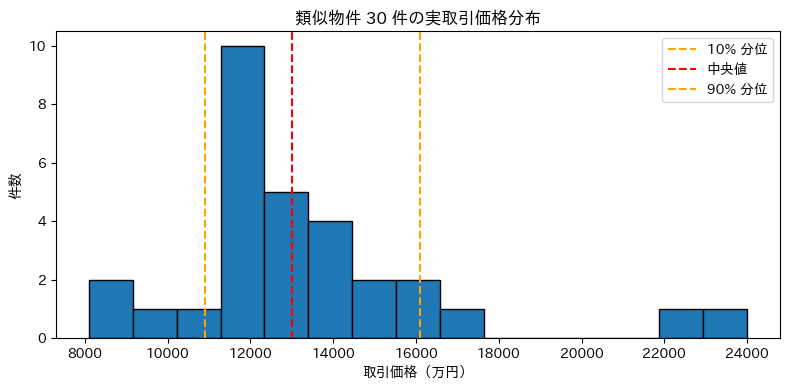

In [6]:
# 実証的信頼区間のプレビュー
similar_30 = find_similar_properties(df, target_idx=target_idx, n_neighbors=30)
prices = similar_30["取引価格（総額）"].astype(int)

p10, p50, p90 = np.percentile(prices, [10, 50, 90])
print(f"類似物件 {len(similar_30)} 件の実取引価格")
print(f" 10% ~ 90% 区間: {p10:,.0f} ~ {p90:,.0f} 円")
print(f" 中央値：{p50:,.0f} 円")

# 分布を確認
plt.figure(figsize=(8, 4))
plt.hist(prices / 10_000, bins=15, edgecolor="black")
plt.axvline(p10 / 10_000, color="orange", linestyle="--", label="10% 分位")
plt.axvline(p50 / 10_000, color="red", linestyle="--", label="中央値")
plt.axvline(p90 / 10_000, color="orange", linestyle="--", label="90% 分位")
plt.xlabel("取引価格（万円）")
plt.ylabel("件数")
plt.title("類似物件 30 件の実取引価格分布")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
"""エッジケース確認"""

# (1) 希少物件: 同種類・同市区町村が少ない/無い
try:
  similar_c = find_similar_properties(df, target_idx=target_c.index[0], n_neighbors=5)
  print(f"希少物件: {len(similar_c)} 件取得")
  display(similar_c[DISPLAY_COLS])
except ValueError as e:
  print(f"希少物件: 母集団が空 → {e}")

# （２）欠損のある物件
missing_target = df[df["築年数"].isna()].head(1)
if not missing_target.empty:
  try:
    similar_m = find_similar_properties(df, target_idx=missing_target.index[0], n_neighbors=5)
    print(f"\n欠損あり物件: {len(similar_m)} 件取得（距離計算はNaNになる可能性）")
    display(similar_m[DISPLAY_COLS] + ["similarity_distance"])
  except ValueError as e:
    print(f"\n欠損あり物件: {e}")

# （３）存在しない target_idx
try:
  find_similar_properties(df, target_idx=9999999, n_neighbors=5)
except ValueError as e:
  print(f"\n存在しない idx: {e}")

# （４）recent_first の効果確認
s_recent = find_similar_properties(df, target_idx=target_idx, n_neighbors=10, recent_first=True)
s_nearest = find_similar_properties(df, target_idx=target_idx, n_neighbors=10, recent_first=False)
print(f"\nrecent_first=True: 取引年 {s_recent["取引年"].tolist()}")
print(f"recent_first=False: 距離 {s_nearest["取引年"].round(3).tolist()}")

希少物件: 5 件取得


,住所,最寄駅：名称,最寄駅：距離（分）,面積（㎡）,築年数,建物の構造,改装,取引年,取引四半期,取引価格（総額）,similarity_distance
355,東京都千代田区永田町,永田町,2.0,140,18.0,RC,NaN,2025,4,680000000,4.331176
45,東京都千代田区平河町,永田町,1.0,160,17.0,RC,NaN,2025,3,750000000,3.756677
466,東京都千代田区九段北,九段下,1.0,185,35.0,鉄骨造,0.0,2025,2,260000000,3.110332
31,東京都千代田区四番町,市ケ谷,4.0,155,19.0,RC,NaN,2025,2,720000000,3.799313
536,東京都千代田区四番町,市ケ谷,3.0,145,19.0,RC,0.0,2025,2,720000000,4.114221



存在しない idx: 対象 index が DataFrame に存在しません: target_idx=9999999

recent_first=True: 取引年 [2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025]
recent_first=False: 距離 [2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025]


## Phase 3: Quantile 区間 vs 実証的区間の比較

Phase 2（Quantile Regression）の予測区間と、Phase 3（類似物件の実取引価格）の
実証的区間を **1 物件に対して並べて可視化**し、`compare_intervals()` で信頼度を判定する。

- 2 区間が重なり、中央値も近い → **高信頼**
- 食い違う → **要人手査定**

実証的区間は Phase 2 の 90% 区間と比較できるよう `lower_q=0.05 / upper_q=0.95` で揃える。

In [8]:
# Phase 3 検証: Quantile 区間（Phase 2）と実証的区間（Phase 3）を比較する
from src.modeling.train import prepare_dataset
from src.visualization.prediction import (
    LOWER_COL,
    MEDIAN_COL,
    UPPER_COL,
    compare_intervals,
    empirical_interval_from_similar,
    load_quantile_models,
    predict_with_interval,
)

# 分位点モデル（low / med / high）をロード
models = load_quantile_models(project_root / "models")

# 学習時と同じ前処理で特徴量を用意（取引価格・取引年などは学習対象外として除外済み）
x_all, y_all = prepare_dataset()
print(f"特徴量: {x_all.shape} / モデル α = {sorted(models.keys())}")

特徴量: (39659, 33) / モデル α = [0.05, 0.5, 0.95]


In [9]:
def appraise(target_idx: int, n_similar: int = 30) -> tuple[dict, dict, dict]:
    """対象物件に Quantile 区間と実証的区間を計算し、比較結果を返す.

    Returns:
        (quantile_interval, empirical_interval, comparison) のタプル。
    """
    # Phase 2: Quantile Regression による予測区間（円スケール）
    x_target = x_all.loc[[target_idx]]
    q = predict_with_interval(models, x_target, return_yen=True).iloc[0]
    quantile_interval = {
        LOWER_COL: float(q[LOWER_COL]),
        MEDIAN_COL: float(q[MEDIAN_COL]),
        UPPER_COL: float(q[UPPER_COL]),
    }

    # Phase 3: 類似物件の実取引価格から作る実証的区間
    # （Phase 2 の 90% 区間と揃えるため 0.05 / 0.95 を指定）
    empirical_interval = empirical_interval_from_similar(
        df, target_idx, n_similar=n_similar, lower_q=0.05, upper_q=0.95
    )

    comparison = compare_intervals(quantile_interval, empirical_interval)
    return quantile_interval, empirical_interval, comparison

In [10]:
def plot_interval_comparison(
    target_idx: int,
    quantile_interval: dict,
    empirical_interval: dict,
    comparison: dict,
) -> None:
    """Quantile 区間と実証的区間を横棒で並べて可視化する."""
    man = 10_000  # 円 → 万円
    actual = float(df.loc[target_idx, "取引価格（総額）"])

    fig, ax = plt.subplots(figsize=(11, 3.2))
    rows = [
        ("Quantile 区間\n(Phase 2)", quantile_interval, "steelblue", 1),
        ("実証的区間\n(Phase 3)", empirical_interval, "coral", 0),
    ]
    for label, iv, color, y in rows:
        lo, med, hi = (
            iv[LOWER_COL] / man,
            iv[MEDIAN_COL] / man,
            iv[UPPER_COL] / man,
        )
        ax.plot([lo, hi], [y, y], color=color, linewidth=6, alpha=0.5, solid_capstyle="round")
        ax.plot(med, y, "o", color=color, markersize=12)
        ax.text(lo, y + 0.15, f"{lo:,.0f}", ha="center", fontsize=9, color=color)
        ax.text(hi, y + 0.15, f"{hi:,.0f}", ha="center", fontsize=9, color=color)
        ax.text(med, y - 0.28, f"中央 {med:,.0f}万", ha="center", fontsize=10, color=color)

    # 対象物件自身の実成約額を縦線で表示
    ax.axvline(actual / man, color="black", linestyle="--", alpha=0.7, label="実取引価格")

    ax.set_yticks([0, 1])
    ax.set_yticklabels([rows[1][0], rows[0][0]])
    ax.set_ylim(-0.7, 1.7)
    ax.set_xlabel("価格（万円）")
    ax.set_title(
        f"予測区間の比較  判定: {comparison['flag']}  "
        f"(中央値乖離 {comparison['divergence'] * 100:.1f}% / "
        f"overlap={comparison['has_overlap']} / 類似 {comparison['n_similar_used']} 件)"
    )
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

対象: 東京都渋谷区大山町 / 面積 60㎡ / 築 7.0年
実取引価格    : 12,000 万円
Quantile 中央値: 13,889 万円
実証的 中央値  : 13,000 万円
判定          : 高信頼（中央値乖離 6.8%）


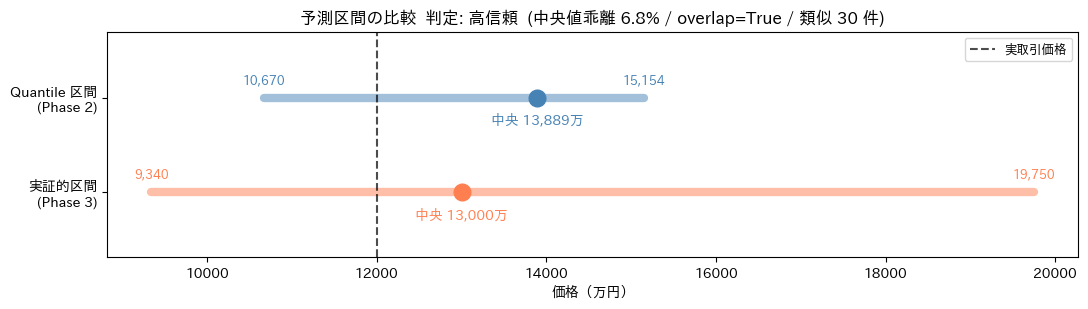

In [11]:
# パターン A（都心の標準物件）で検証
target_idx = target_a.index[0]
q_iv, e_iv, cmp_result = appraise(target_idx)

man = 10_000
print(
    f"対象: {df.loc[target_idx, '住所']} / "
    f"面積 {df.loc[target_idx, '面積（㎡）']}㎡ / 築 {df.loc[target_idx, '築年数']}年"
)
print(f"実取引価格    : {df.loc[target_idx, '取引価格（総額）'] / man:,.0f} 万円")
print(f"Quantile 中央値: {q_iv[MEDIAN_COL] / man:,.0f} 万円")
print(f"実証的 中央値  : {e_iv[MEDIAN_COL] / man:,.0f} 万円")
print(f"判定          : {cmp_result['flag']}（中央値乖離 {cmp_result['divergence'] * 100:.1f}%）")

plot_interval_comparison(target_idx, q_iv, e_iv, cmp_result)

--- B:郊外: 東京都東村山市多摩湖町 / 判定 高信頼 (類似 30 件) ---


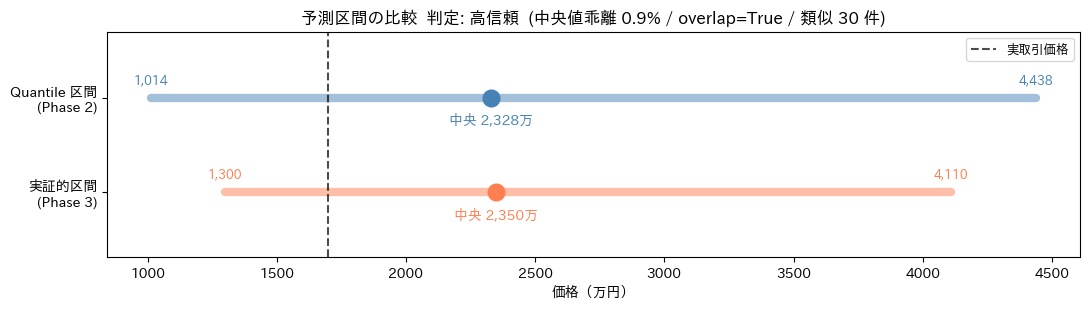

--- C:希少: 東京都千代田区四番町 / 判定 要人手査定 (類似 30 件) ---


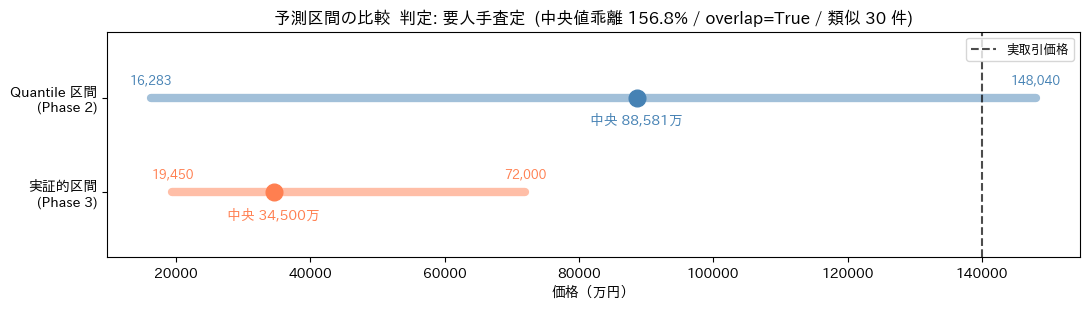

In [12]:
# パターン B（郊外）・C（希少）でも検証し、判定の違いを見る
for label, target in [("B:郊外", target_b), ("C:希少", target_c)]:
    if target.empty:
        print(f"--- {label}: 該当物件なし ---")
        continue
    t_idx = target.index[0]
    if t_idx not in x_all.index:
        print(f"--- {label}: 学習対象外（価格 0 など）でスキップ ---")
        continue
    try:
        q_iv, e_iv, cmp_result = appraise(t_idx)
    except ValueError as err:
        print(f"--- {label}: 区間計算不可 → {err} ---")
        continue
    print(
        f"--- {label}: {df.loc[t_idx, '住所']} / 判定 {cmp_result['flag']} "
        f"(類似 {cmp_result['n_similar_used']} 件) ---"
    )
    plot_interval_comparison(t_idx, q_iv, e_iv, cmp_result)